# Simulating epPCR

To have a good simulation of variant effect screens, we need a realistic synthetic library. That starts with simulating epPCR using the parameters we obtained from the library analysis.

In [ ]:
import numpy as np
import pandas as pd

wt_dna_seq = "GGTTTGAAGCAAAAAATCGTTATCAAAGTTGCTATGGAAGGTAATAACTGTAGATCTAAAGCTATGGCTTTGGTTGCTTCTACTGGTGGTGTTGATTCTGTTGCTTTAGTTGGTGATTTGAGGGATAAAATCGAAGTTGTTGGTTATGGTATCGACCCAATCAAGTTGATTTCTGCCTTGAGAAAGAAAGTTGGTGACGCCGAATTATTGCAAGTTTCTCAAGCTAAGAAGGAT"

mut_freq_matrix = {
    'A': {'C': 0.043356, 'G': 0.926775, 'T': 0.029869},
    'C': {'A': 0.31986, 'G': 0.015746, 'T': 0.952268},
    'G': {'A': 0.956464, 'C': 0.011670, 'T': 0.031866},
    'T': {'A': 0.021744, 'C': 0.929183, 'G': 0.049073},
}

To ensure compatibilty with generating 10^8 sequences, we need to make this extremely fast. There's a few keys to doing that:
1. Handle memory correctly: use batches to prevent RAM exploding trying to mutate all 10^8 sequences at once.
2. Vectorize sequences by encoding bases as integers.
3. Vectorize mutations probabilities and counts, so everything is generated and applied in parallel.

In [70]:
def memory_efficient_epPCR(
        wt_seq: str, 
        num_seq: int, 
        avg_n_mut: float, 
        mut_freq_matrix: dict,
        batch_size: int = 100_000
):
    '''
    Simulate error-prone PCR.
    
    :param wt_seq: WT sequence to mutate.
    :type wt_seq: str
    :param num_seq: Number of mutants to generate.
    :type num_seq: int
    :param avg_n_mut: Average number of mutations per sequence.
    :type avg_n_mut: float
    :param mut_freq_matrix: Dict of dicts providing the mutation frequencies for each nucleotide.
    :type mut_freq_matrix: dict
    :param batch_size: Number of sequences to generate in parallel.
    :type batch_size: float
    '''
    # Define nucleotide encodings
    base_map = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    reverse_map = np.array(['A', 'C', 'G', 'T'])

    # Encode WT sequence
    wt_encoded = np.array([base_map[b] for b in wt_seq], dtype=np.int8)
    L = len(wt_encoded)

    for start_idx in range(0, num_seq, batch_size):
        # Ensure batch size is not greater than what's left
        current_bs = min(batch_size, num_seq-start_idx)

        # Initialize the output DataFrame structure for this batch
        # We fill 'sequence' later; 'mutations' defaults to empty string
        batch_df = pd.DataFrame({
            'n_subs': np.zeros(current_bs, dtype=int),
            'gene_mutations': ["" for _ in range(current_bs)], 
            'sequence': [wt_seq] * current_bs
        })

        # Create sequence matrix (batch_size, seq_length)
        seq_matrix = np.tile(wt_encoded, (current_bs, 1))

        # Determine how many mutations each sequence gets
        n_muts = np.random.poisson(avg_n_mut, size=current_bs)
        batch_df['n_subs'] = n_muts
        total_muts = np.sum(n_muts)

        # Generate coordinates for every mutation (variant #, position)
        # For rows, make a list of numbers repeating the row index as 
        # many times as there are mutations for that variant
        row_idx = np.repeat(np.arange(current_bs), n_muts)

        # For cols, choose a random int between 0 and the len of the seq
        # for each mutation
        col_idx = np.random.randint(0,L,size=total_muts)

        # Get WT bases at each site
        wt_bases = seq_matrix[row_idx, col_idx]

        # Apply mutations
        # Here, we group mutations by base identity, generating all mutations for WT 'A', for example
        new_bases = np.zeros(total_muts, dtype=np.int8)

        for base_char, base_int in base_map.items():
            # Find all bases that match the current base
            mask = (wt_bases == base_int)
            if not np.any(mask): continue # skip if theres none

            # Construct probability vector for this base
            probs = []
            targets = ['A', 'C', 'G', 'T']
            for t in targets:
                if t == base_char:
                    probs.append(0.0) # don't mutate to the same thing
                else:
                    # Grab the probability for the corresponding mut target
                    probs.append(mut_freq_matrix[base_char][t])

            p_arr = np.array(probs)
            p_arr /= p_arr.sum() # normalize to sum to 1.0

            # Choose mutations for all of this WT base
            choices = np.random.choice([0,1,2,3], size=np.sum(mask), p=p_arr)
            new_bases[mask] = choices

        # Update the matrix
        seq_matrix[row_idx, col_idx] = new_bases

        # Build mutation strings
        # Decode integers back to chars for the labels: "A" "12" "G"
        wt_chars = reverse_map[wt_bases]
        new_chars = reverse_map[new_bases]
        
        # Create a dataframe of *just* the mutations to use groupby
        # This is faster than looping through the main matrix
        mut_events = pd.DataFrame({
            'row_idx': row_idx,
            'desc': [f"{w}{p}{n}" for w, p, n in zip(wt_chars, col_idx+1, new_chars)]
        })
        
        # Aggregate mutations by row index (e.g. 0 -> "A12G, T99C")
        grouped_muts = mut_events.groupby('row_idx')['desc'].apply(lambda x: " ".join(x))
        
        # Map these strings back to the main batch DataFrame
        batch_df.loc[grouped_muts.index, 'gene_mutations'] = grouped_muts
        
        # Decode the full sequences
        # (Vectorized string join is not native to numpy, list comp is best approach)
        batch_df['sequence'] = ["".join(row) for row in reverse_map[seq_matrix]]
        yield batch_df

In [71]:
batches = []
for batch in memory_efficient_epPCR(wt_dna_seq, 360_000, 3.43, mut_freq_matrix):
    batches.append(batch)

mut_df = pd.concat(batches, ignore_index=True)
mut_df

,n_subs,gene_mutations,sequence
0,2,G165A G186A,GGTTTGAAGCAAAAAATCGTTATCAAAGTTGCTATGGAAGGTAATA...
1,3,T106C C32T G100A,GGTTTGAAGCAAAAAATCGTTATCAAAGTTGTTATGGAAGGTAATA...
2,7,A227G G6A T92C G175A G85A T234C T57C,GGTTTAAAGCAAAAAATCGTTATCAAAGTTGCTATGGAAGGTAATA...
3,4,G31A A12G T144C T57C,GGTTTGAAGCAGAAAATCGTTATCAAAGTTACTATGGAAGGTAATA...
4,0,,GGTTTGAAGCAAAAAATCGTTATCAAAGTTGCTATGGAAGGTAATA...
...,...,...,...
359995,1,T145C,GGTTTGAAGCAAAAAATCGTTATCAAAGTTGCTATGGAAGGTAATA...
359996,4,G85A G199A A59G A59G,GGTTTGAAGCAAAAAATCGTTATCAAAGTTGCTATGGAAGGTAATA...
359997,3,T205C G73A T105C,GGTTTGAAGCAAAAAATCGTTATCAAAGTTGCTATGGAAGGTAATA...
359998,6,T99C C201T T33C G133A A54G C68T,GGTTTGAAGCAAAAAATCGTTATCAAAGTTGCCATGGAAGGTAATA...


In [72]:
import plotly.express as px

fig = px.histogram(mut_df, 'n_subs')
fig.show()

In [73]:
from scripts.construct_variant_table import construct_variant_table

mut_df['library'] = 'library'
mut_df['sample'] = 'lib'

variant_table = construct_variant_table(
    aligned_reads_df=mut_df,
    wt_dna_file='configs/pikh1_dna_seq.fasta'
)

Constructing variant table...


In [74]:
variant_table.variant_count_df

,library,sample,barcode,count,variant_call_support,codon_substitutions,aa_substitutions,n_codon_substitutions,n_aa_substitutions
0,library,lib,GGTTTGAAGCAAAAAATCGTTATCAAAGTTGCTATGGAAGGTAATA...,11414,1,,,0,0
1,library,lib,GGTTTGAAGCAAAAAATCGTTATCAAAGTTGCTATGGAAGGTAATA...,189,1,ATC54ACC,I54T,1,1
2,library,lib,GGTTTGAAGCAAAAAATCGTTATCAAAGTTGCTATGGAAGGTAATA...,188,1,TGT17TAT,C17Y,1,1
3,library,lib,GGTTTGAAGCAAAAAATCGTTATCAAAGTTGCTATGGAAGGTAATA...,188,1,GTT37GCT,V37A,1,1
4,library,lib,GGTTTGAAGCAAAAAATCGTTATCAAAGTTGCTATGGAAGGTAATA...,188,1,GGT38AGT,G38S,1,1
...,...,...,...,...,...,...,...,...,...
273175,library,lib,TGTTTGATGCAAAAAATCGTCATCAAAGTTGCTATGGAAGGTAATA...,1,1,GGT1TGT AAG3ATG GTT7GTC GAC66GAT,G1C K3M,4,2
273176,library,lib,TGTTTGGAGCAAAAAATCGTTATCAAAGCTGCTATGGAAGGTAATA...,1,1,GGT1TGT AAG3GAG GTT10GCT GAT39AAT GAA45GAG ATC...,G1C K3E V10A D39N I51T K62E,7,6
273177,library,lib,TGTTTGGAGCAAAAAATCGTTATCAAAGTTGCTATGGAAGGTAATA...,1,1,GGT1TGT AAG3GAG AAA43AGG CAA74TAA,G1C K3E K43R Q74*,4,4
273178,library,lib,TGTTTGGAGCAAAAAATCGTTATCAAAGTTTCTATGGAAGGTAATA...,1,1,GGT1TGT AAG3GAG GCT11TCT GAT39AAT GTT46ATT GGT...,G1C K3E A11S D39N V46I G50D R61G S73F,8,8


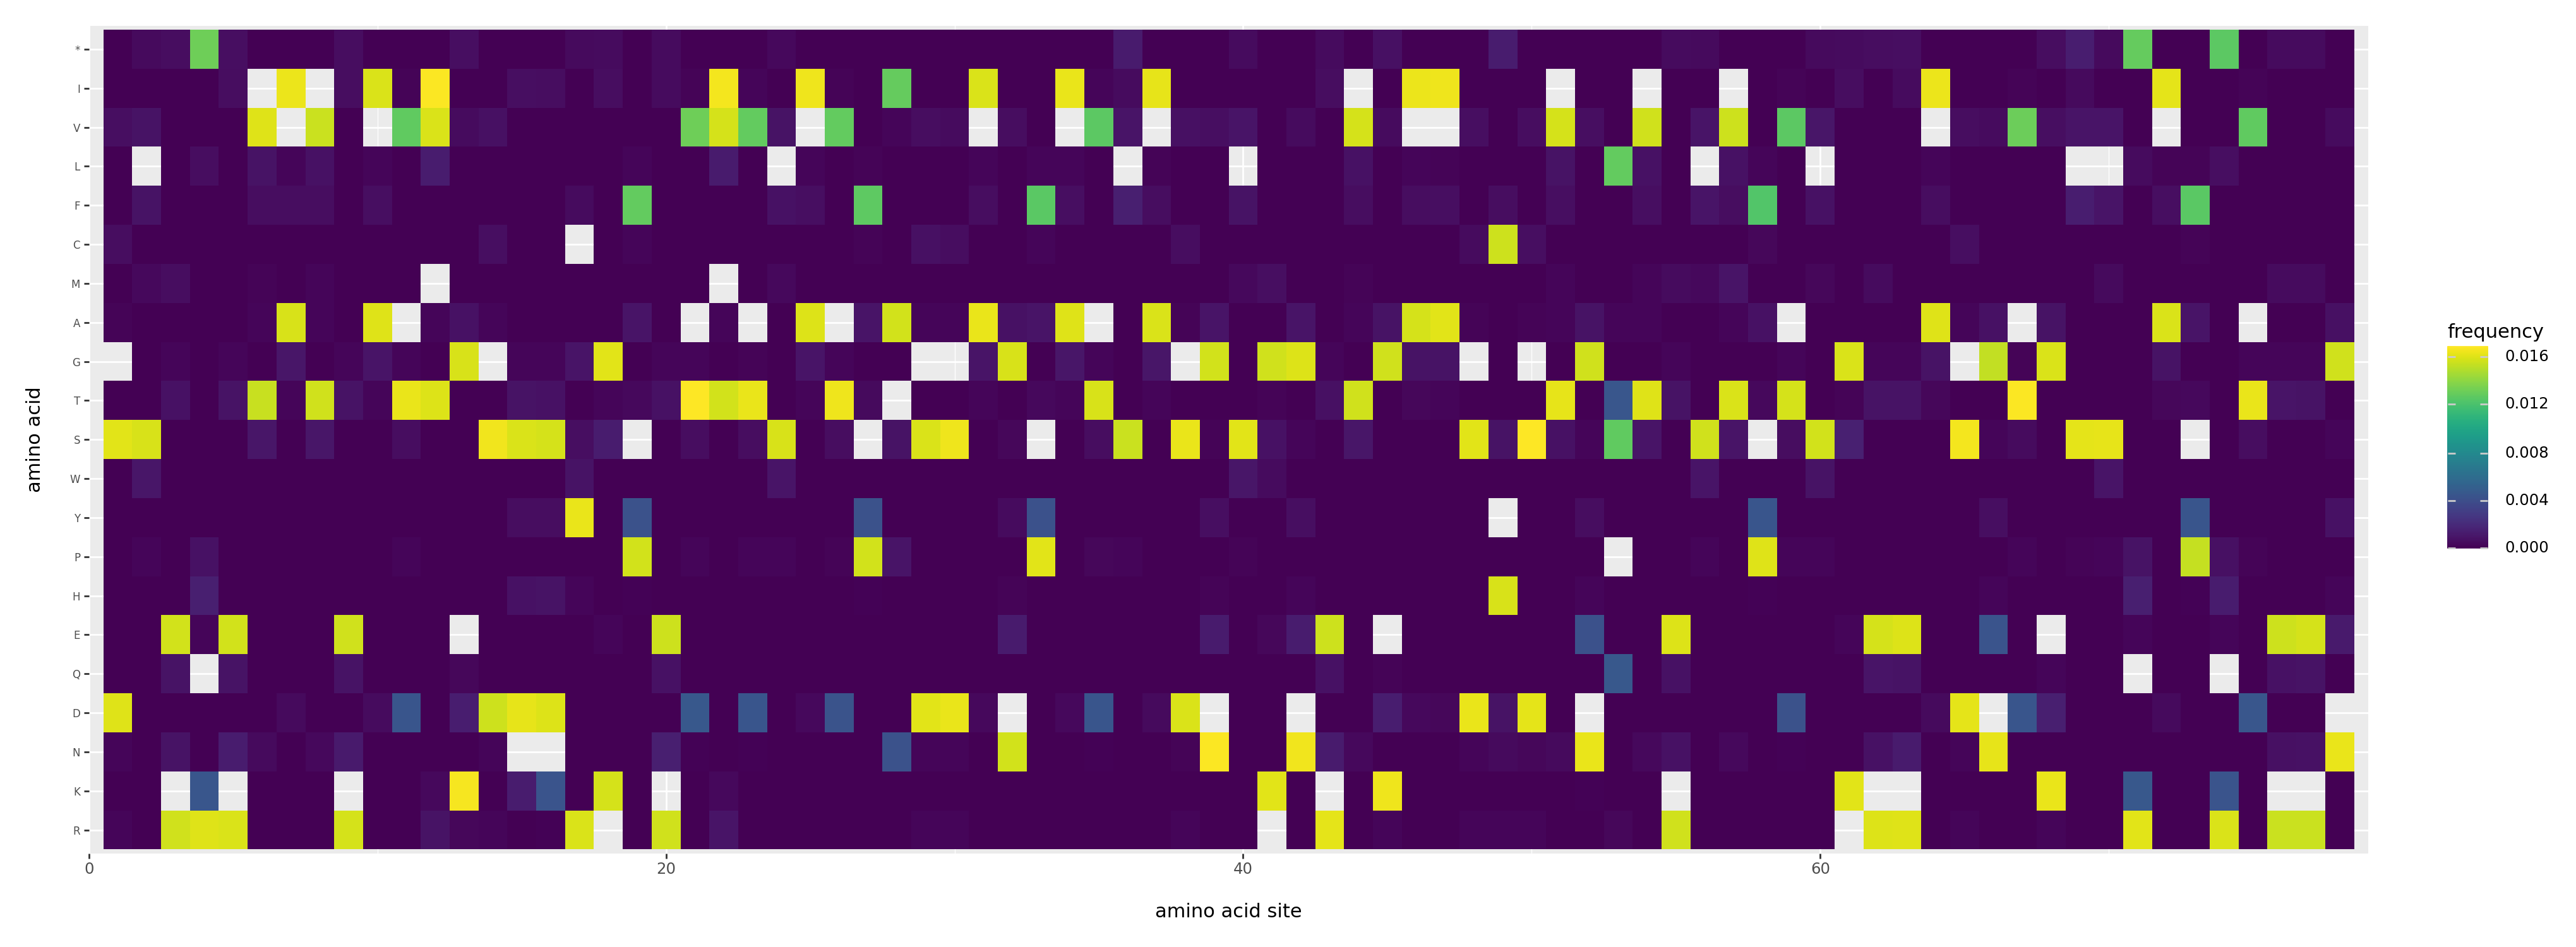

In [75]:
variant_table.plotMutHeatmap('all', 'aa', count_or_frequency='frequency', widthscale=4, heightscale=3, samples=None)

How do things look different with the Mutazyme II mutation frequencies? Referencing their table in their [manual](https://www.agilent.com/cs/library/usermanuals/public/200552.pdf).

Unfortunately, they don't specify things in exactly the way I want. Let's see if we work out the equivalent so that's it compatible with my parameters.

In [80]:
# I just let Gemini take this one over, but it makes sense
def get_mutazyme_matrix():
    """
    Calculates the conditional probability matrix for Mutazyme II
    based on the Stratagene datasheet percentages.
    """
    # ---------------------------------------------------------
    # 1. Raw Data from Datasheet (Percentages)
    # ---------------------------------------------------------
    # These are the combined frequencies (e.g., "A->G plus T->C")
    # We exclude Indels (5.5%) to normalize for substitutions only.
    
    # Transitions
    Ts_AG_TC = 17.5
    Ts_GA_CT = 25.5
    
    # Transversions
    Tv_AT_TA = 28.5
    Tv_AC_TG = 4.7
    Tv_GC_CG = 4.1
    Tv_GT_CA = 14.1
    
    # ---------------------------------------------------------
    # 2. Split Pairs (Strand Symmetry)
    # ---------------------------------------------------------
    # Divide by 2 to get the frequency for a single direction
    # e.g., if A->G + T->C = 17.5, then A->G is 8.75
    
    # From A
    a_to_g = Ts_AG_TC / 2  # Transition
    a_to_t = Tv_AT_TA / 2  # Transversion (High in Mutazyme)
    a_to_c = Tv_AC_TG / 2  # Transversion
    
    # From G
    g_to_a = Ts_GA_CT / 2  # Transition
    g_to_c = Tv_GC_CG / 2  # Transversion
    g_to_t = Tv_GT_CA / 2  # Transversion
    
    # From T (Mirrors A)
    t_to_c = a_to_g
    t_to_a = a_to_t
    t_to_g = a_to_c
    
    # From C (Mirrors G)
    c_to_t = g_to_a
    c_to_g = g_to_c
    c_to_a = g_to_t

    # ---------------------------------------------------------
    # 3. Normalize to Conditional Probabilities
    # ---------------------------------------------------------
    # P(Target | Parent) = Freq(Mutation) / Total_Freq_of_Parent
    
    # Calculate total 'share' of mutations for each parent
    total_a = a_to_g + a_to_t + a_to_c
    total_g = g_to_a + g_to_c + g_to_t
    total_t = t_to_c + t_to_a + t_to_g
    total_c = c_to_t + c_to_g + c_to_a
    
    matrix = {
        'A': {
            'C': round(a_to_c / total_a, 4),
            'G': round(a_to_g / total_a, 4),
            'T': round(a_to_t / total_a, 4),
        },
        'C': {
            'A': round(c_to_a / total_c, 4),
            'G': round(c_to_g / total_c, 4),
            'T': round(c_to_t / total_c, 4),
        },
        'G': {
            'A': round(g_to_a / total_g, 4),
            'C': round(g_to_c / total_g, 4),
            'T': round(g_to_t / total_g, 4),
        },
        'T': {
            'A': round(t_to_a / total_t, 4),
            'C': round(t_to_c / total_t, 4),
            'G': round(t_to_g / total_t, 4),
        }
    }
    
    return matrix

Constructing variant table...


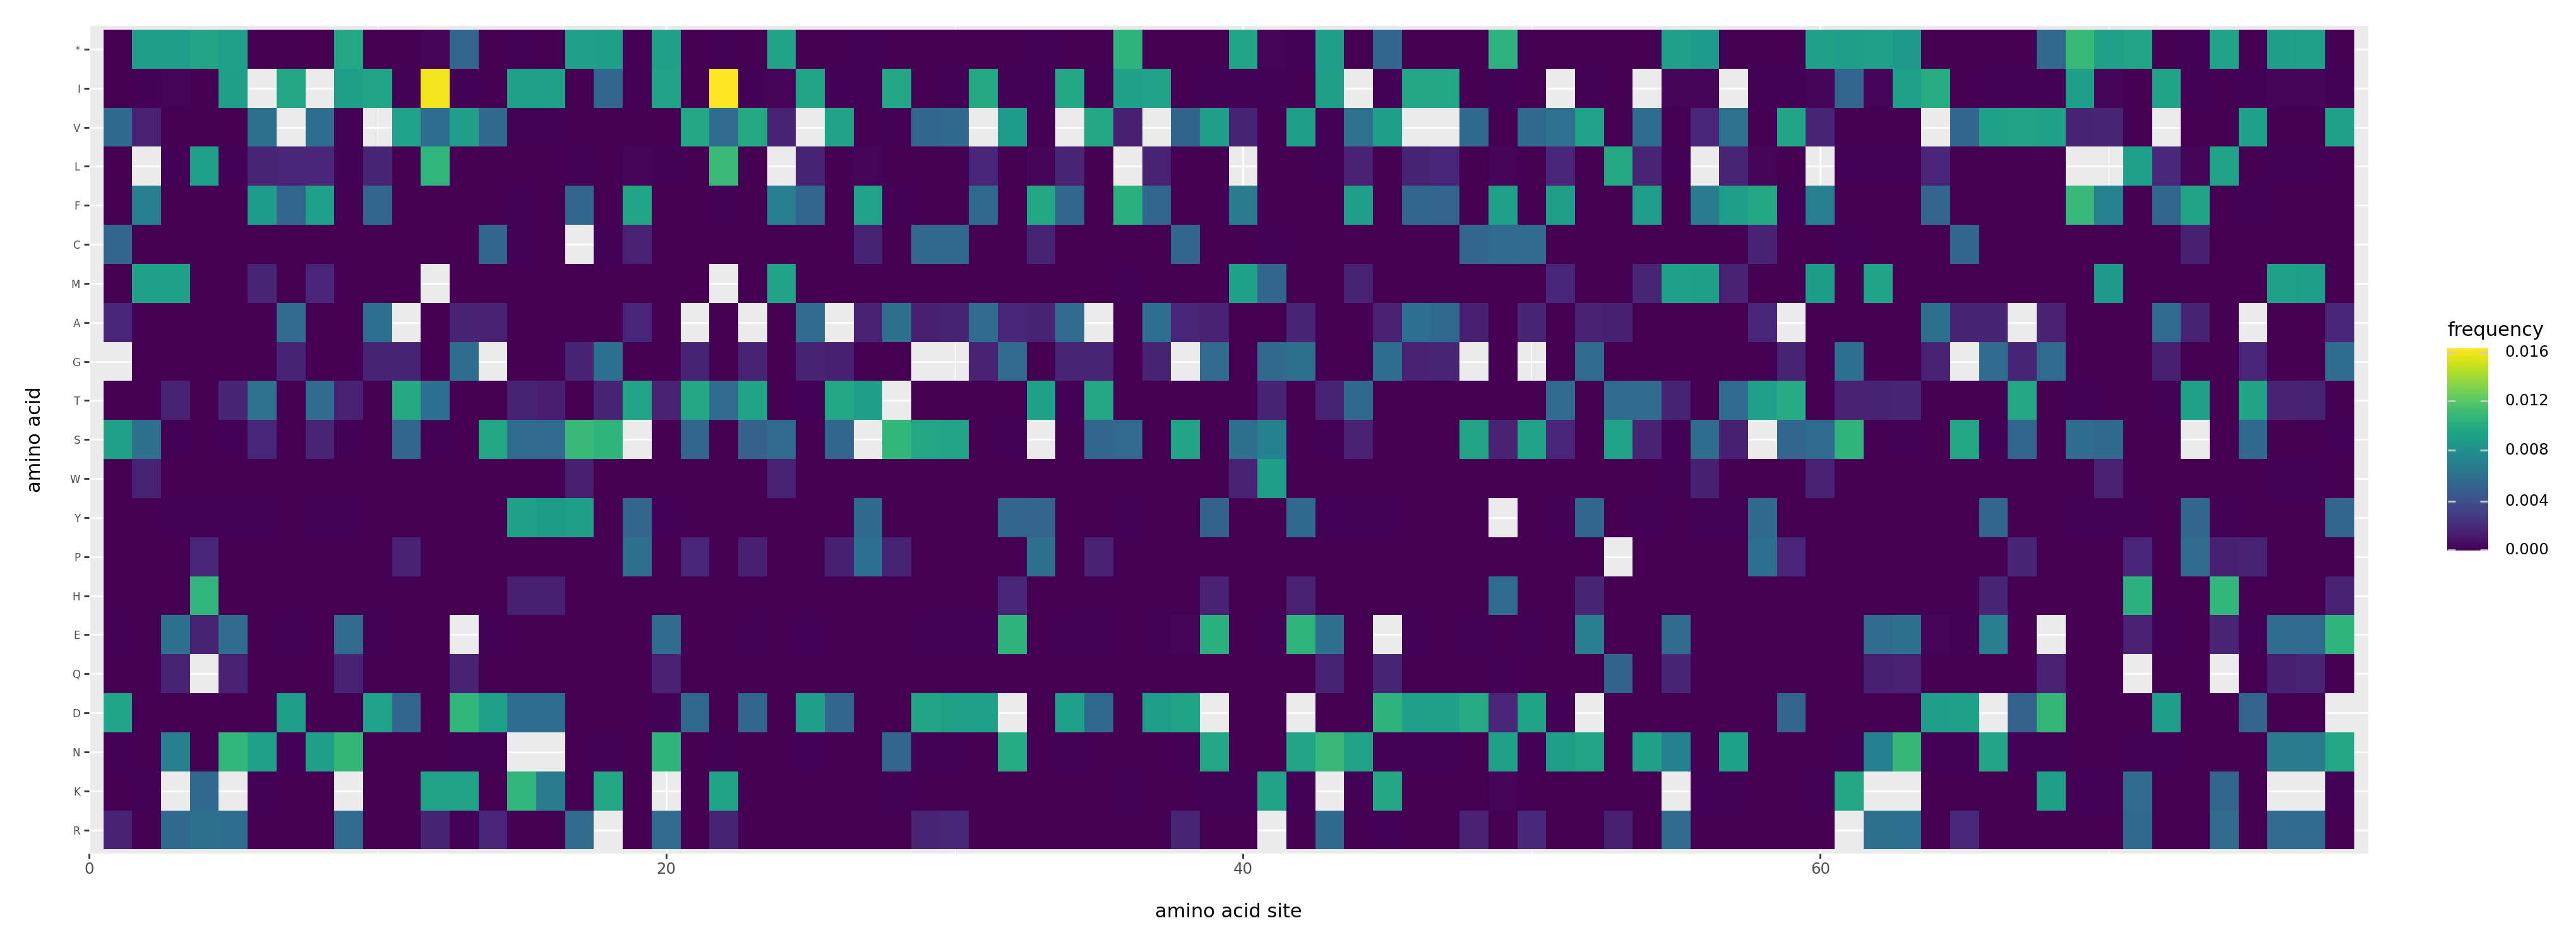

In [81]:
# Parameters derived from Stratagene Mutazyme II Datasheet
mutazyme_matrix = get_mutazyme_matrix()

batches = []
for batch in memory_efficient_epPCR(wt_dna_seq, 360_000, 3.43, mutazyme_matrix):
    batches.append(batch)

mut_df = pd.concat(batches, ignore_index=True)
mut_df['library'] = 'library'
mut_df['sample'] = 'lib'

variant_table = construct_variant_table(
    aligned_reads_df=mut_df,
    wt_dna_file='configs/pikh1_dna_seq.fasta'
)

variant_table.plotMutHeatmap('all', 'aa', count_or_frequency='frequency', widthscale=4, heightscale=3, samples=None)